In [1]:
import os
import yaml
from glob import glob
from pprint import pprint

import matplotlib.pyplot as plt

from mejiro.utils import util

# read configuration file
import mejiro
config_file = os.path.join(os.path.dirname(mejiro.__file__), 'data', 'mejiro_config', 'roman_data_challenge_rung_1.yaml')  # _unlabeled
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

if config['dev']:
    config['pipeline_label'] += '_dev'

In [2]:
data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '02')

pickles = sorted(glob(os.path.join(data_dir, '*', '*.pkl')))
# pickles = sorted(glob(os.path.join(data_dir, '*.pkl')))
sample_lenses = [util.unpickle(f) for f in pickles]
print(f'Found {len(sample_lenses)} system(s) in {data_dir}')

Found 49 system(s) in /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/02


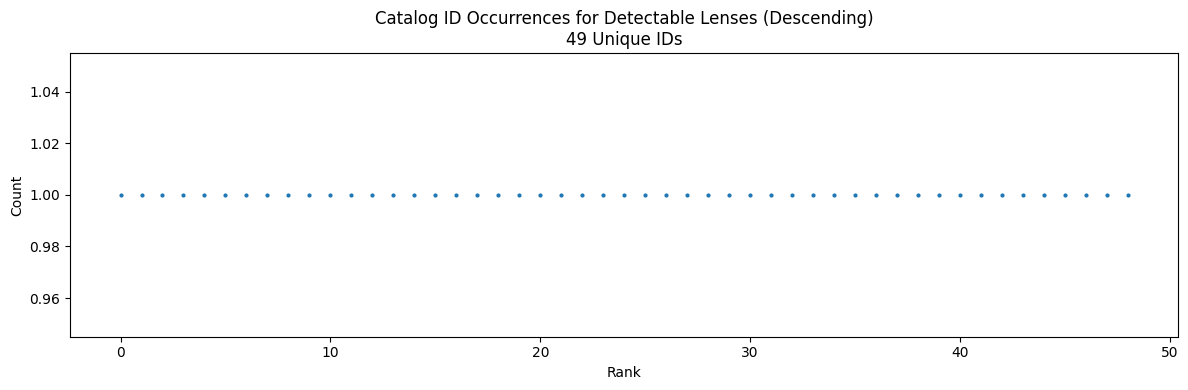

In [3]:
from collections import Counter

catalog_id_counts = Counter()

for lens in sample_lenses:
    catalog_id_counts[lens.physical_params['matched_source']['id']] += 1

sorted_counts = sorted(catalog_id_counts.values(), reverse=True)

plt.figure(figsize=(12, 4))
plt.plot(range(len(sorted_counts)), sorted_counts, '.', markersize=4)
plt.xlabel('Rank')
plt.ylabel('Count')
plt.title(f'Catalog ID Occurrences for Detectable Lenses (Descending)\n{len(catalog_id_counts)} Unique IDs')
plt.tight_layout()
plt.show()

In [4]:
lens.source_light_model

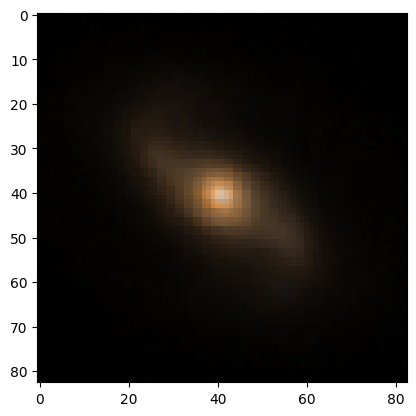

In [12]:
from astropy.visualization import make_lupton_rgb

rgb = make_lupton_rgb(lens.kwargs_params['source_images']['F158'], lens.kwargs_params['source_images']['F129'], lens.kwargs_params['source_images']['F106'], Q=4)

plt.imshow(rgb)
plt.show()

In [6]:
sample_lens = sample_lenses[0]

print(sample_lens)

StrongLens(name=roman_data_challenge_rung_1_00000000, coords=None, z_lens=1.4439999999999988, z_source=3.98775640716071)


In [7]:
flags = []

for l in sample_lenses:
    if type(l.use_jax) is list:
        flags.extend(l.use_jax)
    else:
        flags.append(l.use_jax)

print(f'percentage of use_jax=True: {100*sum(flags)/len(flags):.1f}% in {len(flags)} flags')

percentage of use_jax=True: 0.0% in 196 flags


In [8]:
# from collections import Counter

# galaxy_ids = [l.physical_params.get('galaxy_id') for l in sample_lenses]
# repeat_list = []

# counts = Counter(galaxy_ids)
# for galaxy_id, count in counts.items():
#     print(f'galaxy_id {galaxy_id} appears {count} times')
#     repeat_list.append(count)

In [9]:
# import matplotlib.pyplot as plt
# import numpy as np

# plt.figure(figsize=(6, 4))
# plt.plot(np.linspace(0, len(repeat_list), len(repeat_list)), sorted(repeat_list, reverse=True))
# plt.title(f'Repeated COSMOS Sources\n{len(galaxy_ids)} Strong Lenses, {len(repeat_list)} Unique Sources')
# plt.xlabel('Rank in Number of Repetitions')
# plt.ylabel('Number of Repetitions')
# plt.show()

In [10]:
pprint(sample_lens.__dict__)

{'coords': None,
 'cosmo': FlatLambdaCDM(name='Planck18',
                        H0=<Quantity 67.66 km / (Mpc s)>,
                        Om0=0.30966,
                        Tcmb0=<Quantity 2.7255 K>,
                        Neff=3.046,
                        m_nu=<Quantity [0.  , 0.  , 0.06] eV>,
                        Ob0=0.04897),
 'interpol_deflection_map': None,
 'kwargs_lens_macromodel': None,
 'kwargs_model': {'cosmo': FlatLambdaCDM(name='Planck18',
                                         H0=<Quantity 67.66 km / (Mpc s)>,
                                         Om0=0.30966,
                                         Tcmb0=<Quantity 2.7255 K>,
                                         Neff=3.046,
                                         m_nu=<Quantity [0.  , 0.  , 0.06] eV>,
                                         Ob0=0.04897),
                  'lens_light_model_list': ['HERNQUIST_ELLIPSE'],
                  'lens_model_list': ['NFW_ELLIPSE_CSE',
                          